In [1]:
# IMPORT ALL PROJECT MODULES

from ball_observation import BallObservation
from ball_trajectory import Ball, simulate_n_balls
from particle_filter import ParticleFilter
from nball_particle_filter import NBallParticleFilter
import importlib
import plotting
importlib.reload(plotting)

from plotting import (
    BallTrajectoryPlot,
    BallObservationPlot,
    ParticleFilterTrajectoryPlot,
    nBallTrajectoryPlot,
    BallCountPlot,
    TrackingErrorPlot,
    merge_dropout,
    extract_dropout_regions,
    compute_tracking_errors
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


TIME STEP|| TRAJECTORY(x,y)1:
------------------------------
t= 0.00s || (  0.00,   0.00)
t= 0.10s || (  5.73,   3.92)
t= 0.20s || ( 11.47,   7.74)
t= 0.30s || ( 17.20,  11.46)
t= 0.40s || ( 22.94,  15.08)
t= 0.50s || ( 28.67,  18.60)
t= 0.60s || ( 34.40,  22.03)
t= 0.70s || ( 40.14,  25.36)
t= 0.80s || ( 45.87,  28.59)
t= 0.90s || ( 51.61,  31.72)
t= 1.00s || ( 57.34,  34.75)
t= 1.10s || ( 63.07,  37.69)
t= 1.20s || ( 68.81,  40.53)
t= 1.30s || ( 74.54,  43.27)
t= 1.40s || ( 80.28,  45.91)
t= 1.50s || ( 86.01,  48.45)
t= 1.60s || ( 91.75,  50.90)
t= 1.70s || ( 97.48,  53.25)
t= 1.80s || (103.21,  55.50)
t= 1.90s || (108.95,  57.65)
t= 2.00s || (114.68,  59.70)
t= 2.10s || (120.42,  61.65)
t= 2.20s || (126.15,  63.51)
t= 2.30s || (131.88,  65.27)
t= 2.40s || (137.62,  66.93)
t= 2.50s || (143.35,  68.49)
t= 2.60s || (149.09,  69.96)
t= 2.70s || (154.82,  71.32)
t= 2.80s || (160.55,  72.59)
t= 2.90s || (166.29,  73.76)
t= 3.00s || (172.02,  74.83)
t= 3.10s || (177.76,  75.81)
t= 3.20s |

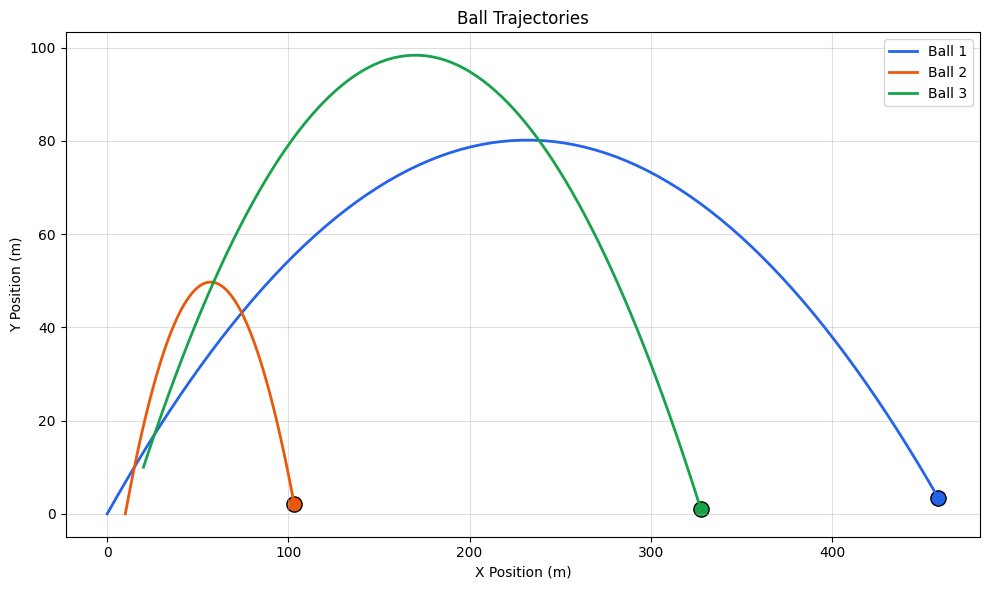

In [2]:

SAMPLE_SETS = {
        1: [  # Different angles, wide separation 
            {"initial_position": [0,  0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [20, 0], "speed": 60, "angle_degrees": 30},
        ],
        2: [  # Steep vs shallow 
            {"initial_position": [0,  0], "speed": 55, "angle_degrees": 75},
            {"initial_position": [15, 0], "speed": 45, "angle_degrees": 25},
        ],
        3: [  # Similar speeds and angles 
            {"initial_position": [0, 0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [5, 0], "speed": 52, "angle_degrees": 47},
        ],
        4: [  # Fast vs slow, different heights
            {"initial_position": [0,  0], "speed": 70, "angle_degrees": 35},
            {"initial_position": [10, 0], "speed": 35, "angle_degrees": 65},
            {"initial_position": [20, 10], "speed": 55, "angle_degrees": 50},
        ],
    }

SAMPLE   = 4      
launches = SAMPLE_SETS[SAMPLE]
DT       = 0.1

trajectories = simulate_n_balls(launches, dt=DT)
for i, traj in enumerate(trajectories):
    print(f"\nTIME STEP|| TRAJECTORY(x,y){i+1}:")
    print("------------------------------")
    for t, x, y in traj:
        print(f"t={t:5.2f}s || ({x:6.2f}, {y:6.2f})")
# Visualize trajectory
plotter = BallTrajectoryPlot(launches)
plotter.visualize()

TIME STEP ||             BALL 0              ||             BALL 1              ||             BALL 2              ||
          ||     True.      |      Obs.      ||     True.      |      Obs.      ||     True.      |      Obs.      ||
---------------------------------------------------------------------------------------------------------------------
t= 0.00s  ||(   0.0,   0.0) |       N/A      ||(  10.0,   0.0) |       N/A      ||(  20.0,  10.0) | (  22.3,  11.7)||
t= 0.10s  ||(   5.7,   3.9) | (   8.3,   6.5)||(  11.5,   3.1) | (   9.4,   0.6)||(  23.5,  14.1) | (  23.3,  13.0)||
t= 0.20s  ||(  11.5,   7.7) | (   8.7,  13.0)||(  13.0,   6.0) | (  14.3,   7.5)||(  27.1,  18.1) | (  28.0,  21.1)||
t= 0.30s  ||(  17.2,  11.5) | (  17.4,  11.8)||(  14.4,   8.9) | (  11.2,   6.7)||(  30.6,  22.1) |       N/A      ||
t= 0.40s  ||(  22.9,  15.1) | (  24.2,  16.5)||(  15.9,  11.7) | (   5.5,   9.3)||(  34.1,  25.9) | (  32.6,  24.2)||
t= 0.50s  ||(  28.7,  18.6) | (  27.0,  20.8)||(  17.4, 

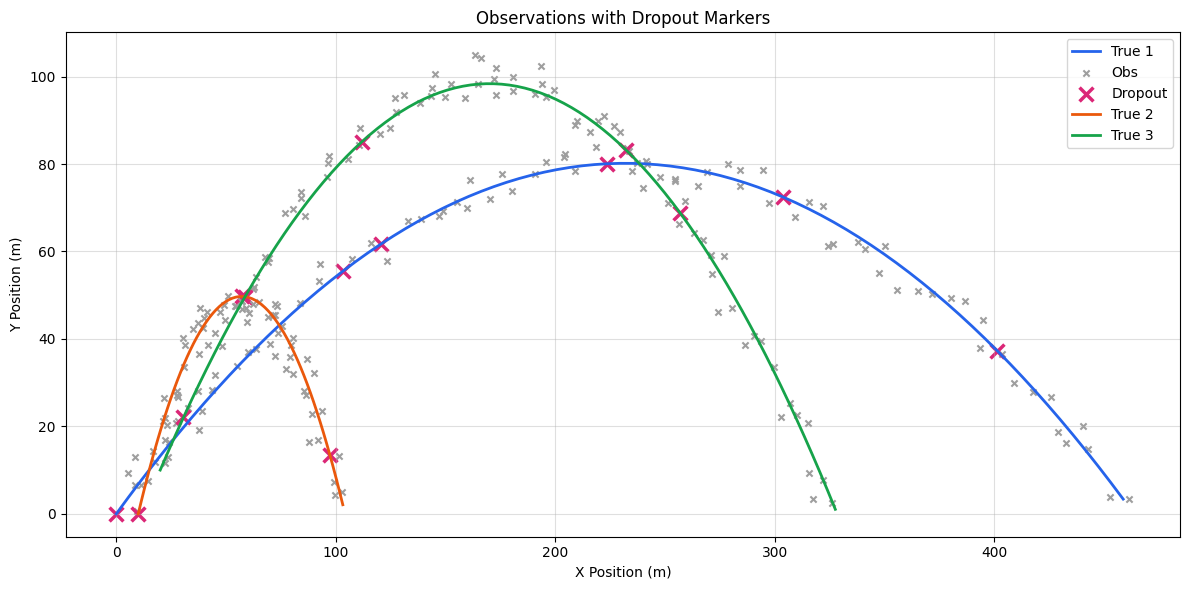

In [3]:
#BallObservation
N_BALLS      = len(launches)
NOISE_STDDEV = 3.0
DROPOUT_PROB = 0.05
observers     = [BallObservation(traj, noise_stddev=NOISE_STDDEV, dropout_prob=DROPOUT_PROB)
                     for traj in trajectories]
obs_sequences = [obs.simulate_observations() for obs in observers]

# Precompute dropout regions for TrackingErrorPlot
dropout_regions = [merge_dropout(seq, min_duration=0.0) for seq in obs_sequences]

n_steps       = max(len(seq) for seq in obs_sequences)

_cw = 15  
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'TIME STEP':^10}||" + "".join(f"{'BALL '+str(b):^{_cw*2+3}}||" for b in range(N_BALLS)))
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'':10}||" + "".join(f"{'True.':^{_cw}} | {'Obs.':^{_cw}}||" for b in range(N_BALLS)))
print("-" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))

fmt = lambda v: f"({v[0]:6.1f},{v[1]:6.1f})" if v is not None else f"{'N/A':^{_cw}}"

for step_idx in range(n_steps):
    t        = next(obs_sequences[b][step_idx][0] for b in range(N_BALLS) if step_idx < len(obs_sequences[b]))
    obs_list = [obs_sequences[b][step_idx][1] if step_idx < len(obs_sequences[b]) else None for b in range(N_BALLS)]
    true_pos = [trajectories[b][min(step_idx, len(trajectories[b])-1)][1:3] for b in range(N_BALLS)]

    print(f"t={t:5.2f}s  ||" + "".join(
        f"{fmt(true_pos[b])} | {fmt(obs_list[b])}||"
        for b in range(N_BALLS)))


plotter = BallObservationPlot(trajectories, obs_sequences)
plotter.visualize()

Initializing 5000 particles for 3 balls in area 100.0x100.0
TIME STEP ||             BALL 0              ||             BALL 1              ||             BALL 2              ||
          ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||
---------------------------------------------------------------------------------------------------------------------
t= 0.00s  ||      N/A       | (  22.0,  12.8)||      N/A       | (  29.1,  36.5)||(  22.3,  11.7) | ( -28.0,  29.9)||
t= 0.10s  ||(   8.3,   6.5) | (  14.7,   4.7)||(   9.4,   0.6) | (   4.8,  15.8)||(  23.3,  13.0) | (  26.3,  16.1)||
t= 0.20s  ||(   8.7,  13.0) | (  13.3,  13.0)||(  14.3,   7.5) | (  28.7,  21.6)||(  28.0,  21.1) | (  28.7,  21.6)||
t= 0.30s  ||(  17.4,  11.8) | (  16.7,  14.5)||(  11.2,   6.7) | (  31.5,  27.6)||      N/A       | (  31.5,  27.6)||
t= 0.40s  ||(  24.2,  16.5) | (  24.3,  21.0)||(   5.5,   9.3) | (  13.7,  17.9)||(  32.6,  24.2) | (  33.8,  30.4

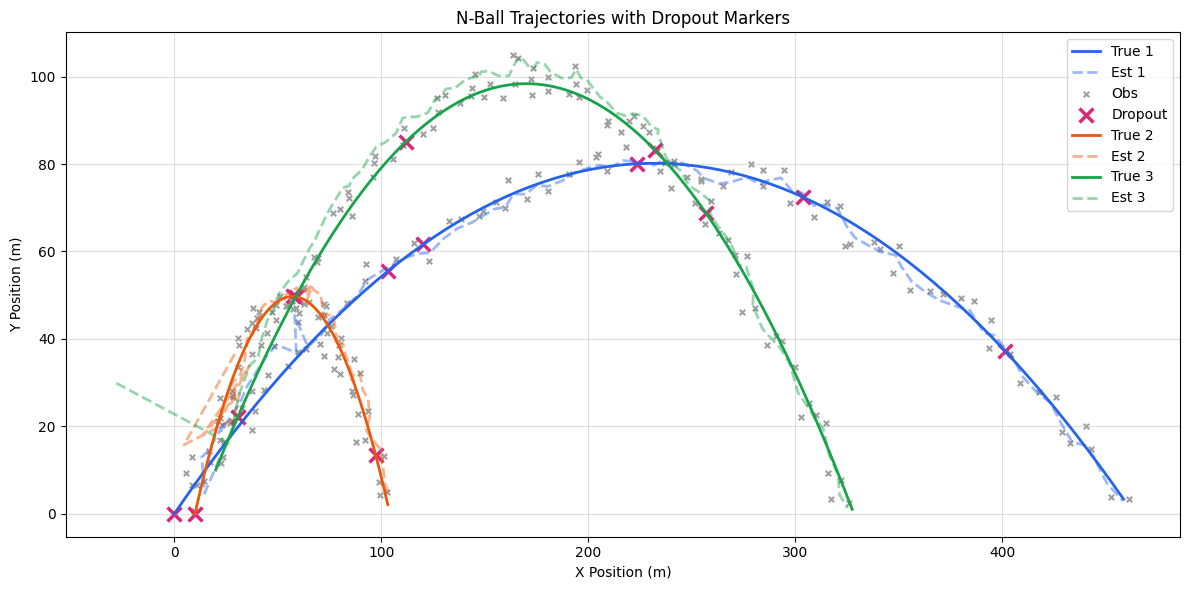

In [4]:
def assign_estimates(est: np.ndarray, true_positions: list) -> np.ndarray:
    
    assigned = np.empty_like(est)
    used = set()
    for b, tp in enumerate(true_positions):
        tp   = np.array(tp)
        best = min((j for j in range(len(est)) if j not in used),
                    key=lambda j: np.linalg.norm(est[j, :2] - tp))
        assigned[b] = est[best]
        used.add(best)
    return assigned

N_BALLS      = len(launches)

pf = NBallParticleFilter(num_particles=5000, n_balls=N_BALLS, noise_stddev=NOISE_STDDEV, area=100.0, noise=NOISE_STDDEV/2)

estimated_trajectories = {i: [] for i in range(N_BALLS)}

# Use longest sequence so no ball is cut short
n_steps = max(len(seq) for seq in obs_sequences)

_cw = 15  # width of each obs/est value cell
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'TIME STEP':^10}||" + "".join(f"{'BALL '+str(b):^{_cw*2+3}}||" for b in range(N_BALLS)))
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'':10}||" + "".join(f"{'Obs.':^{_cw}} | {'Est.':^{_cw}}||" for b in range(N_BALLS)))
print("-" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))

fmt = lambda v: f"({v[0]:6.1f},{v[1]:6.1f})" if v is not None else f"{'N/A':^{_cw}}"
time_values = []
observed_balls = []
estimated_balls = []


for step_idx in range(n_steps):
    t        = next(obs_sequences[b][step_idx][0] for b in range(N_BALLS) if step_idx < len(obs_sequences[b]))
    obs_list = [obs_sequences[b][step_idx][1] if step_idx < len(obs_sequences[b]) else None for b in range(N_BALLS)]
    true_pos = [trajectories[b][min(step_idx, len(trajectories[b])-1)][1:3] for b in range(N_BALLS)]
    est      = assign_estimates(pf.step(dt=DT, observations=obs_list), true_pos)

    for b in range(N_BALLS):
        if step_idx < len(trajectories[b]):
            estimated_trajectories[b].append(est[b])

    print(f"t={t:5.2f}s  ||" + "".join(
        f"{fmt(obs_list[b])} | {fmt(est[b, :2] if step_idx < len(trajectories[b]) else None)}||"
        for b in range(N_BALLS)))


nBallTrajectoryPlot(
    trajectories=trajectories,
    observations=obs_sequences,
    estimates=[estimated_trajectories[i] for i in range(N_BALLS)]
).visualize()